In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(PaaSc))
suppressPackageStartupMessages(library(ggh4x))
suppressPackageStartupMessages(library(reshape2))


Warning message:
“replacing previous import ‘data.table::shift’ by ‘tictoc::shift’ when loading ‘CelliD’”


In [2]:
#load data
gs_anno = read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/Traits/gs_anno.txt',sep = '\t', header=T)
ct_anno = read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/Traits/ct_anno.txt',sep = '\t', header=T)
meta = read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/TMS/TMS_facs_selected_metadata.tsv',sep = '\t', header=T)
PaaSc.res=read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/TMS/TMS_facs_selected_alltraits_PaaSc_score.tsv')
CelliD.res=read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/TMS/TMS_facs_selected_alltraits_CelliD_score.tsv')
GSD.res=read.table('/sibcb1/bioinformatics/liaoxiqi/PaaSc_Data/TMS/TMS_facs_selected_alltraits_GSDensity_score.tsv')

Fig5A

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <b2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD8+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD8+ α-β T' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_tex

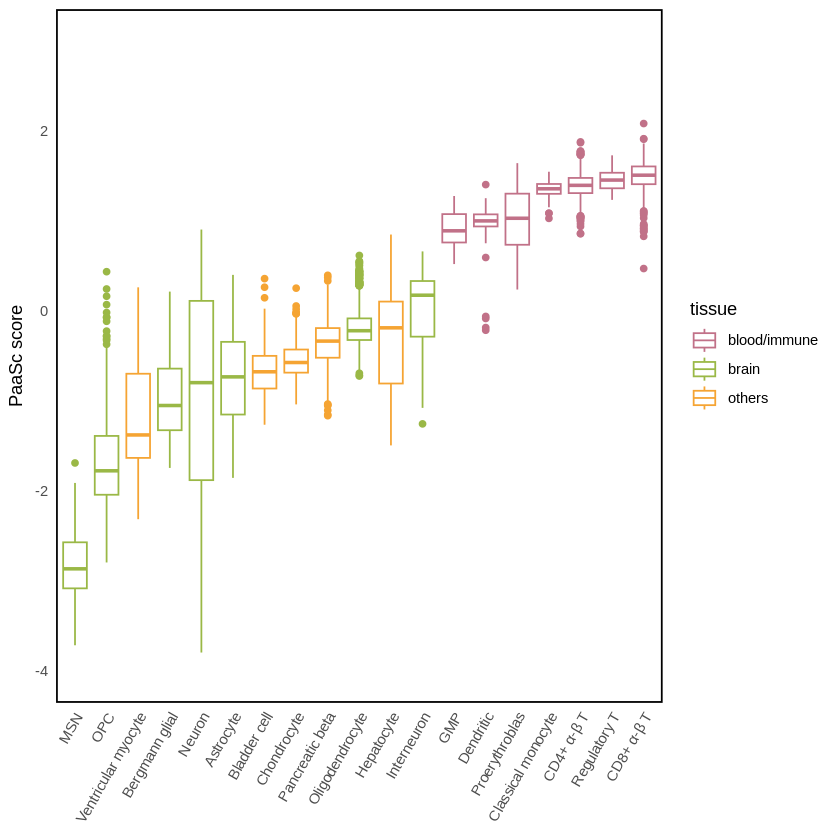

In [4]:
###Fig5A
Fig5A_df = PaaSc.res %>% mutate(celltype=ct_anno$abbreviation[match(meta$cell_ontology_class, ct_anno$CellType)])
Fig5A_df$celltype <- reorder(Fig5A_df$celltype, Fig5A_df[['UKB_460K.blood_LYMPHOCYTE_COUNT']], FUN = median, decreasing = TRUE)
Fig5A_df$tissue <- ct_anno$tissue[match(Fig5A_df$celltype, ct_anno$abbreviation)]

Fig5A <- ggplot(Fig5A_df, aes(x = celltype, y = UKB_460K.blood_LYMPHOCYTE_COUNT,color= tissue)) +
  geom_boxplot() +
  guides(title = NULL)+
  labs(x = NULL, y = 'PaaSc score', title = NULL) +
  scale_color_manual(values = c("blood/immune" = "#C17188", "brain" = "#9AB846", "others" = "#F5A433")) +
  theme_minimal() +
  theme(
    axis.text.x = element_text( angle = 60,hjust = 1, vjust = 1),
    panel.background = element_blank(),
    plot.background = element_blank(),
    panel.border = element_rect( fill = NA, size = 1),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )  +coord_cartesian(ylim = c(-4, 3)) 
Fig5A

ggsave("Fig5A.pdf", Fig5A, width = 6, height = 6, dpi = 300)

Fig5B

number of iterations= 146 
number of iterations= 116 
number of iterations= 158 
number of iterations= 47 
number of iterations= 72 
number of iterations= 58 
number of iterations= 105 
number of iterations= 41 
number of iterations= 84 
number of iterations= 777 
number of iterations= 76 
number of iterations= 67 
number of iterations= 105 
number of iterations= 37 
number of iterations= 28 
number of iterations= 61 
number of iterations= 112 
number of iterations= 68 
number of iterations= 112 
number of iterations= 182 
number of iterations= 56 
number of iterations= 458 
number of iterations= 30 
number of iterations= 31 
number of iterations= 72 
number of iterations= 51 
number of iterations= 65 
number of iterations= 63 
number of iterations= 55 
number of iterations= 32 
number of iterations= 70 
number of iterations= 600 
number of iterations= 39 
number of iterations= 347 
number of iterations= 339 
number of iterations= 256 
number of iterations= 268 
number of iterations= 2

Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”
Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 50 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”


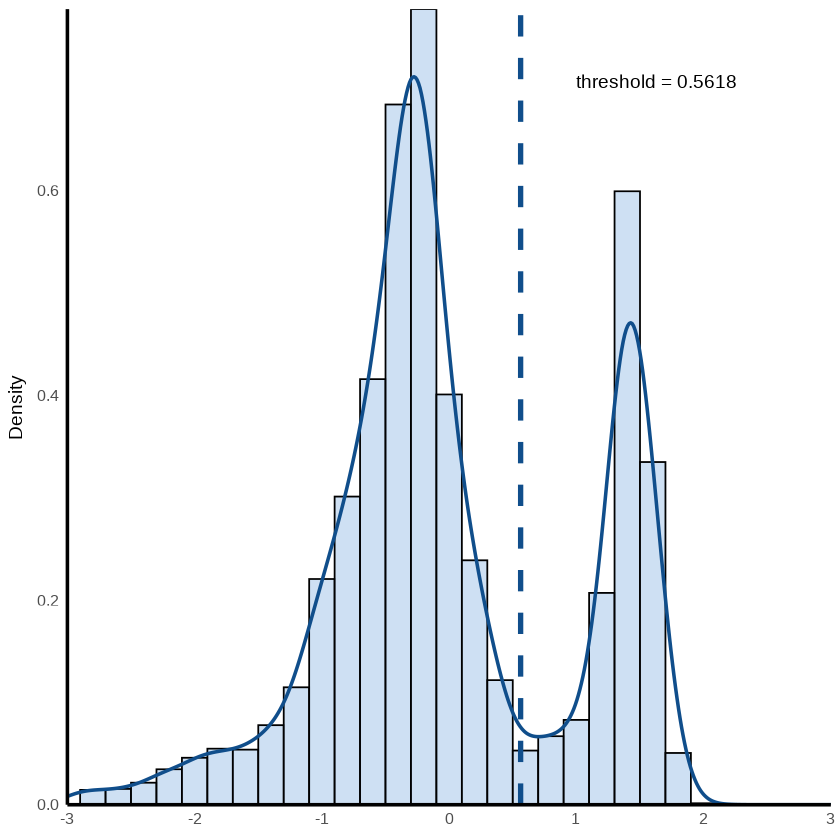

In [71]:
###### Fig5B
set.seed(1)
t='UKB_460K.blood_LYMPHOCYTE_COUNT'
label_data = doBinarization(PaaSc.res, n.cluster = 3)

threshold <- min(PaaSc.res[rownames(label_data[label_data[paste0(t,'.label')] == 'positive', ]), t])

Fig5B<-ggplot(PaaSc.res, aes(x = !!sym(t))) +
  geom_histogram(aes(y = ..density..), 
                 binwidth = 0.2, 
                 fill = "slategray2", 
                 color = "black", 
                 alpha = 0.7, 
                 position = "identity") + 
  geom_density(color = "dodgerblue4", size = 1) + 
  labs(title = NULL, x = NULL, y = "Density") + 
  annotate("text", x = 1, y = 0.7, label = paste0("threshold = ", signif(threshold, 4)), hjust = 0, vjust = 0, color = "black", size = 5) + 
  geom_vline(xintercept = threshold, color = "dodgerblue4", linetype = "dashed", size = 1.5) +
  theme_minimal() +  
  theme(
    panel.grid = element_blank(),  
    axis.title = element_text(size = 14),  
    axis.text = element_text(size = 12),   
    axis.line = element_line(size = 1)     
  ) +
  scale_x_continuous(expand = c(0, 0),limits = c(-3,3)) + 
  scale_y_continuous(expand = c(0, 0))
Fig5B

ggsave("Fig5B.pdf", Fig5B, width = 6, height = 6, dpi = 300)

Fig5C

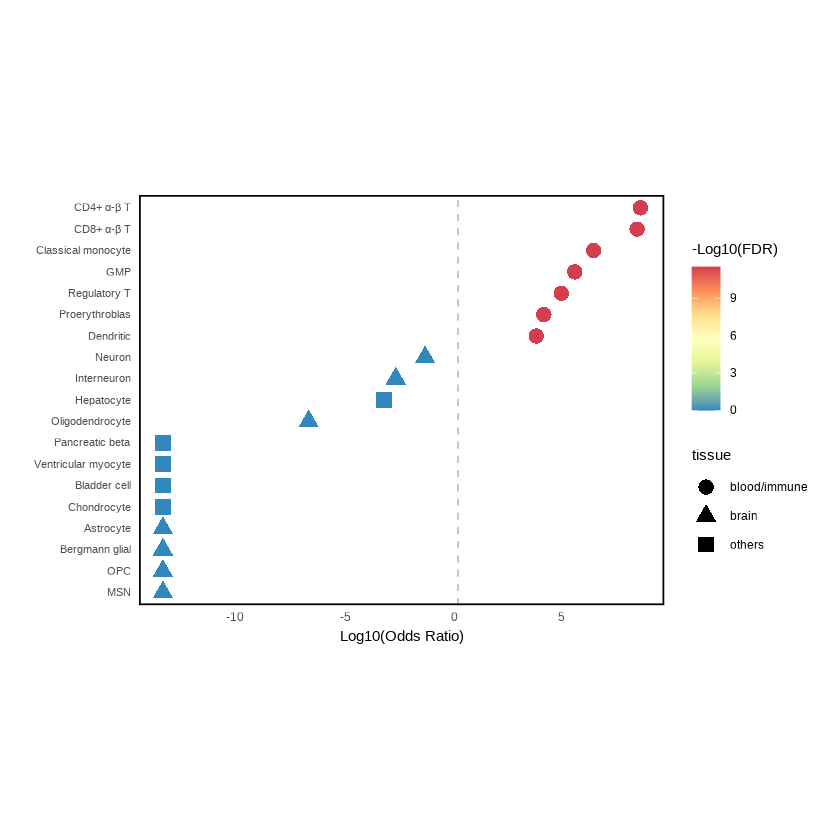

In [72]:
###Fig5C
enrich = lapply(ct_anno$CellType,function(i){   
    cell = meta%>%filter(cell_ontology_class == i) %>%rownames()
    label = factor(label_data[[paste0(t, ".label")]],levels = c('positive','negative'))
    group = factor(ifelse(rownames(label_data) %in% cell,i,'others'),levels = c(i,'others'))
    table_data <- table(label,group)
    test = fisher.test(table_data,alternative = 'greater')
    p_value = test$p.value
    if (is.infinite(test$estimate)) {
        odds_ratio = (table_data[1,1] / table_data[1,2]) / (1 / table_data[2,2])
    } else {
        odds_ratio = test$estimate
    }
    res = data.frame(CellType=ct_anno$abbreviation[match(i, ct_anno$CellType)],Pvalue=p_value,Odds_ratio= odds_ratio)
    return(res)
})
enrich.res=bind_rows(enrich)

enrich.res$Odds_ratio[enrich.res$Odds_ratio == 0] <- 1e-6
enrich.res$log_odds_ratio <- log(enrich.res$Odds_ratio)
enrich.res$padj = p.adjust(enrich.res$Pvalue,method = 'fdr')
enrich.res$padj[enrich.res$padj < 1e-5 ] <- 1e-5
enrich.res$logFDR = -log(enrich.res$padj)
enrich.res$tissue <- ct_anno$tissue[match(enrich.res$CellType, ct_anno$abbreviation)]
enrich.res$CellType <- factor(enrich.res$CellType, levels = enrich.res$CellType[order(enrich.res$log_odds_ratio)])


Fig5C <- ggplot(enrich.res, aes(x=log_odds_ratio, y=CellType))+geom_point( aes(color= logFDR,shape=tissue),fill=NA,size=4)+
  theme_minimal() + 
  theme(
       panel.border = element_rect( fill = NA, size = 1),
    panel.grid = element_blank(),
    axis.text.x = element_text( hjust = 1),
    axis.title.y = element_text(angle = 0, hjust = 1), 
    axis.text.y = element_text(hjust = 1,size = 8)         
  ) +
geom_vline(aes(xintercept = 0),color="gray",linetype="dashed", size = 0.5)+
scale_color_distiller(palette ='Spectral',name ="-Log10(FDR)")+
  xlab("Log10(Odds Ratio)") +                                        
  ylab("") +                                  
  coord_fixed() 
Fig5C
#ggsave("Fig5C.pdf", Fig5C, width = 6, height = 6, dpi = 300)

Fig5D

In [17]:
fisher_test <- function(method.res){
    Score_all=melt(method.res)
    threshold = quantile(Score_all$value, 0.95)
    #mean score
    df_summary <- method.res[,gs_anno$Traits] %>% mutate(CellType = meta$cell_ontology_class)%>%
                  group_by(CellType) %>%
                  summarise(across(where(is.numeric),mean, na.rm = TRUE))%>%
                  pivot_longer(col=-1,values_to = 'Mean',names_to = 'Traits')
    #fisher.test
    fisher.res = data.frame()
    for (t in gs_anno$Traits){
        for (i in ct_anno$CellType){
            cell = meta%>%filter(cell_ontology_class == i) %>%rownames()
            label = factor(ifelse(PaaSc.res[[t]] > threshold ,'positive','negative') ,levels = c('positive','negative'))
            group = factor(ifelse(rownames(PaaSc.res) %in% cell,i,'others'),levels = c(i,'others'))
            table_data <- table(label,group)
            test = fisher.test(table_data,alternative = 'greater')
            if (is.infinite(test$estimate)) {
               odds_ratio = (table_data[1,1] / table_data[1,2]) / (1 / table_data[2,2])
            } else {
              odds_ratio = test$estimate
            }
            res = data.frame(CellType=i,Traits=t,Pvalue=test$p.value,Odds_ratio= odds_ratio)
            fisher.res = rbind(fisher.res,res) 
        }
    }
    df <- merge(df_summary, fisher.res[,1:4], by = c("CellType", "Traits"))%>%
            mutate(CellType=factor(ct_anno$abbreviation[match(CellType, ct_anno$CellType)],levels=ct_anno$abbreviation))%>%
            mutate(Traits=factor(gs_anno$abbreviation[match(Traits, gs_anno$Traits)],levels=rev(gs_anno$abbreviation)))%>%
            mutate(FDR=p.adjust(Pvalue,method = 'fdr'))
    df$ct_col = factor(ct_anno$tissue[match(df$CellType, ct_anno$abbreviation)],levels=c('blood/immune','brain','others'))
    df$gs_col = factor(gs_anno$tissue[match(df$Traits, gs_anno$abbreviation)],levels=c('others','brain','blood/immune'))
    return(df)
}


No id variables; using all as measure variables

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <b1

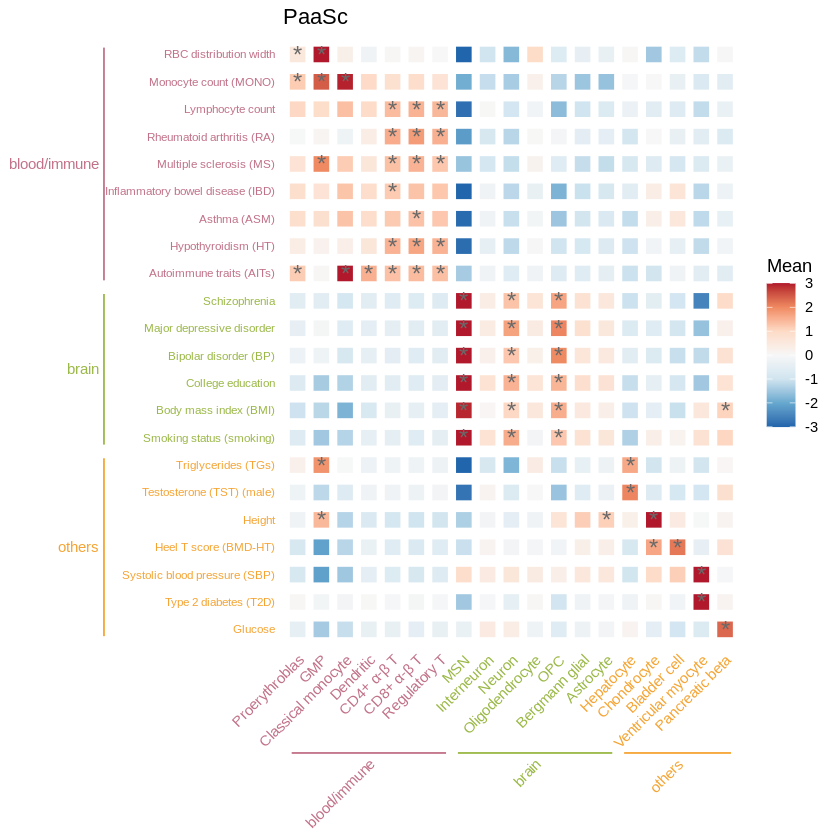

In [18]:
#PaaSc
gs_color=rev(c(rep('#C17188',9),rep('#9AB846',6),rep('#F5A433',7)))
ct_color=c(rep('#C17188',7),rep('#9AB846',7),rep('#F5A433',5))
Fig5D_PaaSc_df = fisher_test(PaaSc.res)
Fig5D_PaaSc_df$Mean[Fig5D_PaaSc_df$Mean >3 ] =3
Fig5D_PaaSc_df$Mean[Fig5D_PaaSc_df$Mean < -3 ] = -3
Fig5D_PaaSc = ggplot(Fig5D_PaaSc_df, aes(x = interaction(CellType,ct_col), y = interaction(Traits,gs_col))) +
                        guides(y = "axis_nested",x = "axis_nested")+
                        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+                               
                        scale_fill_distiller(palette ='RdBu')+
                        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
                        labs(title = 'PaaSc',x=NULL,y=NULL)+
                        theme_minimal() + 
                        theme(
                            panel.grid = element_blank(),                  
                            axis.text.x = element_text(angle = 45, hjust = 1, 
                                                   color = ct_color), 
                            axis.title.y = element_text(angle = 0, hjust = 1),
                            axis.text.y = element_text(hjust = 1, size = 7, 
                                                   color = gs_color),
                            ggh4x.axis.nestline.y = element_line(size = 0.5,colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nesttext.y = element_text(size = 9, colour = c("#F5A433","#9AB846","#C17188")), 
                            ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
                            ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
                      ) 
Fig5D_PaaSc

In [19]:
###GSDensity
GSD_all=melt(GSD.res)
threshold = quantile(GSD_all$value, 0.95)

df_summary <- GSD.res[,gs_anno$Traits]%>% mutate(CellType = meta$cell_ontology_class)%>%
              group_by(CellType) %>%
              summarise(across(where(is.numeric),mean, na.rm = TRUE))%>%
              pivot_longer(col=-1,values_to = 'Mean',names_to = 'Traits')


fisher.res = data.frame()
for (t in gs_anno$Traits){
    for (i in ct_anno$CellType){
        cell = meta%>%filter(cell_ontology_class == i) %>%rownames()
        label = ifelse(GSD.res[[t]] > threshold ,'positive','negative')
        label = factor(label ,levels = c('positive','negative'))
        group = ifelse(rownames(PaaSc.res) %in% cell,i,'others')
        group = factor(group,levels = c(i,'others'))
        table_data <- table(label,group)
        test = fisher.test(table_data,alternative = 'greater')
        p_value = test$p.value
        if (is.infinite(test$estimate)) {
           odds_ratio = (table_data[1,1] / table_data[1,2]) / (1 / table_data[2,2])
        } else {
          odds_ratio = test$estimate
        }
        res = data.frame(CellType=i,Traits=t,Pvalue=p_value,Odds_ratio= odds_ratio)
        fisher.res = rbind(fisher.res,res) 
    }
}


Fig5D_GSD_df <- merge(df_summary, fisher.res[,1:4], by = c("CellType", "Traits"))%>%
            mutate(CellType=factor(ct_anno$abbreviation[match(CellType, ct_anno$CellType)],levels=ct_anno$abbreviation))%>%
            mutate(Traits=factor(gs_anno$abbreviation[match(Traits, gs_anno$Traits)],levels=rev(gs_anno$abbreviation)))%>%
            mutate(FDR=p.adjust(Pvalue,method = 'fdr'))


Fig5D_GSD_df$ct_col = factor(ct_anno$tissue[match(Fig5D_GSD_df$CellType, ct_anno$abbreviation)],levels=c('blood/immune','brain','others'))
Fig5D_GSD_df$gs_col = factor(gs_anno$tissue[match(Fig5D_GSD_df$Traits, gs_anno$abbreviation)],levels=c('others','brain','blood/immune'))

No id variables; using all as measure variables



No id variables; using all as measure variables

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted f

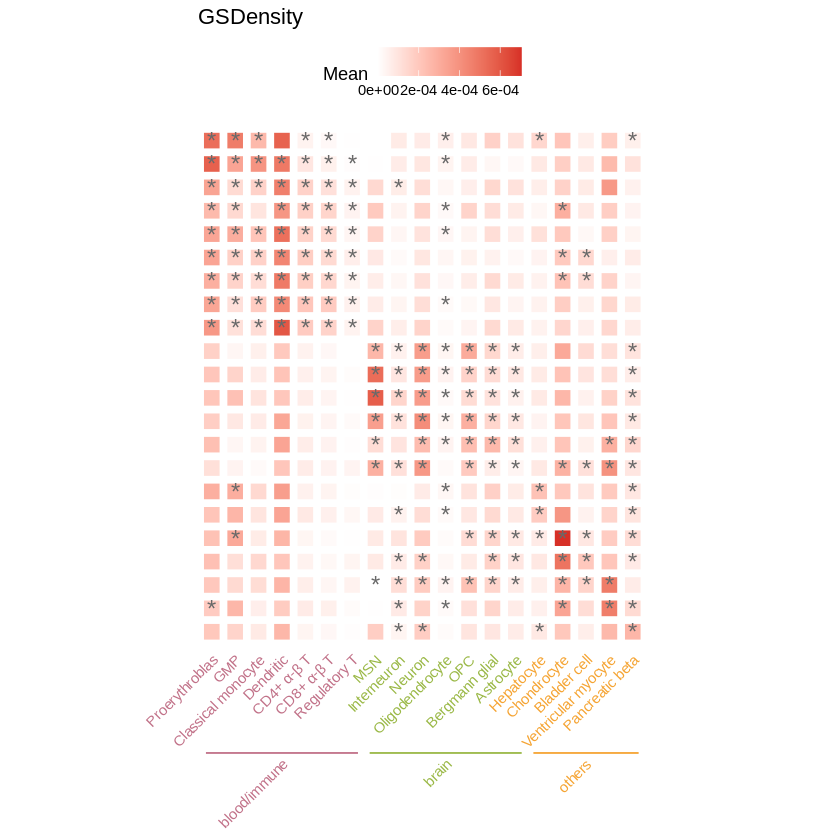

In [20]:
#GSDensity
Fig5D_GSDensity_df = fisher_test(GSD.res)
Fig5D_GSDensity <- ggplot(Fig5D_GSDensity_df, aes(x = interaction(CellType,ct_col), y = Traits,gs_col)) +
        guides(x = "axis_nested")+
        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+
        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
        scale_fill_gradient(high = "#d73027", low = "white")+
        theme_minimal() + 
      theme(
        legend.position = 'top',
        panel.grid = element_blank(),                  
        axis.text.x = element_text(angle = 45, hjust = 1, 
                               color = ct_color), 
        axis.title.y = element_blank(),   
        axis.text.y = element_blank(),   ,
        ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
        ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
      ) + labs(title='GSDensity',x=NULL,y=NULL)+                                    
      coord_fixed()
Fig5D_GSDensity

No id variables; using all as measure variables

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD4+ α-β T' in 'mbcsToSbcs': dot substituted f

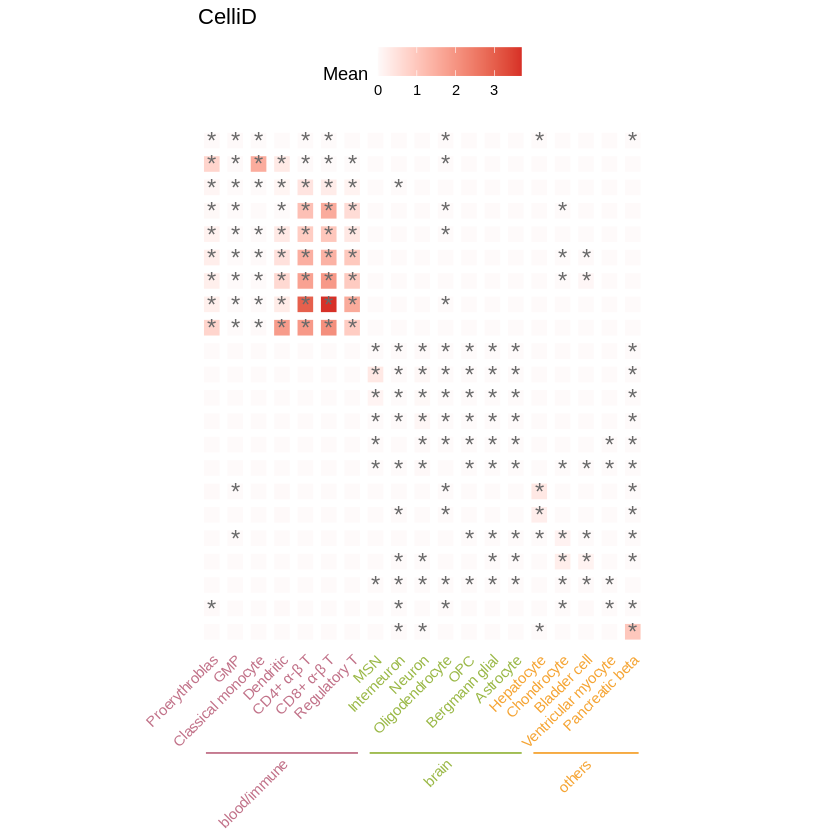

In [14]:
#CelliD
Fig5D_CelliD_df = fisher_test(CelliD.res)
Fig5D_CelliD <- ggplot(Fig5D_CelliD_df, aes(x = interaction(CellType,ct_col), y = Traits)) +
        guides(x = "axis_nested")+
        geom_point(aes(fill=Mean),color='white',shape=22,size=5)+
        geom_text(aes(label = ifelse(FDR < 0.05, "*", "")), size = 5, color = "#696969") +
        scale_fill_gradient(high = "#d73027", low = "#FEFAFA")+
        theme_minimal() + 
      theme(
        legend.position = 'top',
        panel.grid = element_blank(),                  
        axis.text.x = element_text(angle = 45, hjust = 1, 
                               color = ct_color), 
        axis.title.y = element_blank(),
        axis.text.y = element_blank(),
        ggh4x.axis.nestline.x = element_line(size = 0.5,colour = c("#C17188","#9AB846","#F5A433")), 
        ggh4x.axis.nesttext.x = element_text(size = 9, colour = c("#C17188","#9AB846","#F5A433"))
      ) + labs(title='CelliD',x=NULL,y=NULL)+                                    
      coord_fixed()
Fig5D_CelliD